# Layerwise Probe Results

A minimal notebook for loading `results_rebuttal/layerwise_probe` JSON files and plotting accuracy versus probe layer fraction.

In [ ]:
import os
import glob
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections.abc import Sequence
from sklearn.metrics import balanced_accuracy_score

sns.set(style='whitegrid')

In [ ]:
results_dir = 'results_rebuttal/layerwise_probe'
files = glob.glob(os.path.join(results_dir, '**', '*.json'), recursive=True)
rows = []


def _flatten_label_structure(values):
    """Recursively flatten nested predictions/labels regardless of depth."""
    if values is None:
        return []
    if isinstance(values, np.ndarray):
        return values.reshape(-1).tolist()
    if isinstance(values, Sequence) and not isinstance(values, (str, bytes)):
        flattened = []
        for item in values:
            flattened.extend(_flatten_label_structure(item))
        return flattened
    return [values]


def _compute_balanced_accuracy(y_true, y_pred):
    """Compute balanced accuracy from predictions (robust to nesting)."""
    y_true_flat = _flatten_label_structure(y_true)
    y_pred_flat = _flatten_label_structure(y_pred)

    if not y_true_flat or not y_pred_flat:
        return np.nan

    min_len = min(len(y_true_flat), len(y_pred_flat))
    y_true_arr = np.asarray(y_true_flat[:min_len])
    y_pred_arr = np.asarray(y_pred_flat[:min_len])

    try:
        return balanced_accuracy_score(y_true_arr, y_pred_arr)
    except Exception:
        return np.nan


for f in files:
    try:
        with open(f, 'r') as fh:
            data = json.load(fh)
    except Exception:
        continue

    if not isinstance(data, dict):
        continue

    task = data.get('task_name') or data.get('task') or data.get('name') or data.get('eval_task')
    seed = data.get('seed') or data.get('random_seed')
    fraction = data.get('probe_layer') or data.get('probe_layer_fraction') or data.get('fraction') or data.get('layer_fraction')
    linear_probe = data.get('linear_probe')
    model_name = None
    models_names = data.get('models_names')
    if isinstance(models_names, list) and models_names:
        model_name = models_names[0]

    if fraction is None:
        basename = os.path.basename(f)
        tokens = basename.replace('.json', '').split('_')
        for tok in tokens:
            if tok.startswith('Lf') and tok[2:].isdigit():
                fraction = int(tok[2:]) / 100.0
                break

    y_true = data.get('y_test')
    y_pred = data.get('results')

    balanced_accuracy = None
    if isinstance(y_true, list) and isinstance(y_pred, list) and y_true and y_pred:
        balanced_accuracy = _compute_balanced_accuracy(y_true, y_pred)

    if balanced_accuracy is None or np.isnan(balanced_accuracy):
        metrics = data.get('metrics') or {}
        balanced_accuracy = (
            data.get('balanced_accuracy')
            or data.get('bacc')
            or data.get('bal_acc')
            or metrics.get('balanced_accuracy')
            or metrics.get('bacc')
            or metrics.get('bal_acc')
        )

    if balanced_accuracy is not None and not np.isnan(balanced_accuracy) and fraction is not None:
        rows.append({
            'file': f,
            'task': task,
            'seed': seed,
            'fraction': float(fraction),
            'balanced_accuracy': float(balanced_accuracy),
            'linear_probe': linear_probe,
            'model_name': model_name,
        })

columns = ['file', 'task', 'seed', 'fraction', 'balanced_accuracy', 'linear_probe', 'model_name']
df = pd.DataFrame(rows, columns=columns)
df = df.dropna(subset=['fraction', 'balanced_accuracy']).reset_index(drop=True)
df = df[df['linear_probe'].fillna(True)]

print(df.head())
print(sorted(df['task'].dropna().unique().tolist())) if not df.empty else print('No matching results yet.')

In [ ]:
if df.empty:
    agg_all = pd.DataFrame(columns=['fraction', 'mean', 'std', 'count'])
    agg_task = pd.DataFrame(columns=['task', 'fraction', 'mean', 'std', 'count'])
    print('No data to aggregate yet.')
else:
    agg_all = df.groupby('fraction')['balanced_accuracy'].agg(['mean', 'std', 'count']).reset_index().sort_values('fraction')
    agg_task = df.groupby(['task', 'fraction'])['balanced_accuracy'].agg(['mean', 'std', 'count']).reset_index().sort_values(['task', 'fraction'])
    print(agg_all)
    print(agg_task.head())

No data to aggregate yet.


In [ ]:
if agg_all.empty:
    print('No aggregated data to plot yet.')
else:
    plt.figure(figsize=(6, 4))
    plt.errorbar(agg_all['fraction'], agg_all['mean'], yerr=agg_all['std'], fmt='-o', capsize=4)
    plt.xlabel('Probe layer fraction')
    plt.ylabel('Balanced accuracy')
    plt.title('Layerwise probe balanced accuracy (mean ± std)')
    plt.xticks(agg_all['fraction'])
    plt.tight_layout()
    plt.show()

No aggregated data to plot yet.


/home/spanchavati/anaconda3/envs/eeg_bench/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/spanchavati/anaconda3/envs/eeg_bench/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/spanchavati/anaconda3/envs/eeg_bench/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/spanchavati/anaconda3/envs/eeg_bench/lib/python3.10/site-packa

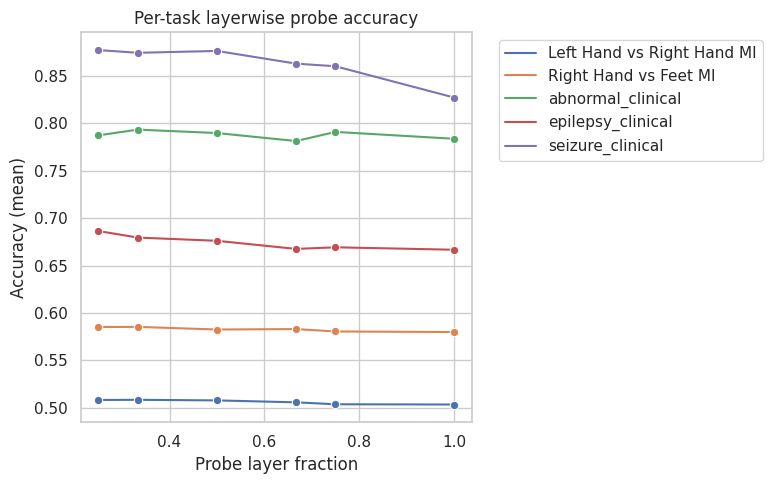

In [ ]:
if agg_task.empty:
    print('No per-task data to plot yet.')
else:
    plt.figure(figsize=(8, 5))
    sns.lineplot(data=agg_task, x='fraction', y='mean', hue='task', marker='o')
    plt.xlabel('Probe layer fraction')
    plt.ylabel('Balanced accuracy (mean)')
    plt.title('Per-task layerwise probe balanced accuracy')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

In [ ]:
out_dir = results_dir
os.makedirs(out_dir, exist_ok=True)

if agg_all.empty:
    print('No plots saved because no layerwise results were found yet.')
else:
    plt.figure(figsize=(6, 4))
    plt.errorbar(agg_all['fraction'], agg_all['mean'], yerr=agg_all['std'], fmt='-o', capsize=4)
    plt.xlabel('Probe layer fraction')
    plt.ylabel('Balanced accuracy')
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, 'layerwise_balanced_accuracy.png'), dpi=150)
    plt.close()

    agg_task.to_csv(os.path.join(out_dir, 'layerwise_per_task_balanced_accuracy.csv'), index=False)
    print('Saved plots and CSV to', out_dir)

No plots saved because no layerwise results were found yet.
